In [2]:
!pip install cantera

Starting equilibrium calculation...
Calculation successful!
H2 yields at [400, 500, 600] °C: [np.float64(0.029658327012868878), np.float64(0.524652162725548), np.float64(2.582833974911082)]


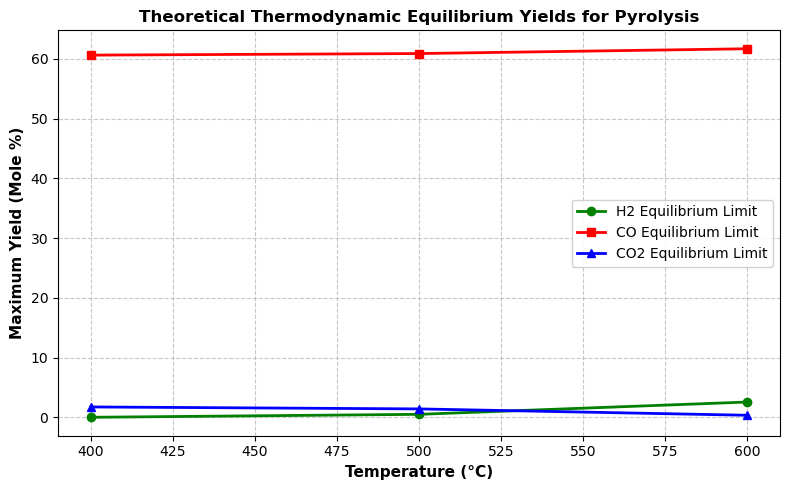

In [4]:
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Cantera's built-in standard gas mechanism file
gas = ct.Solution('gri30.yaml')

# 2. Define feedstock composition (approximate relative moles for pinewood)
feedstock_composition = {'C': 4.16, 'H': 6.20, 'O': 2.68, 'N': 0.05}
pressure_Pa = 101325.0  # 1 atm

# Temperatures to test (matching your physical experiment)
temperatures_C = [400, 500, 600]
h2_yields = []
co_yields = []
co2_yields = []

print("Starting equilibrium calculation...")

for temp_c in temperatures_C:
    temp_k = temp_c + 273.15
    
    # Set temperature, pressure, and initial atomic mix
    gas.TPX = temp_k, pressure_Pa, feedstock_composition
    
    # Minimize Gibbs free energy at constant T and P
    gas.equilibrate('TP')
    
    # Extract mole percentages safely
    h2_yields.append(gas.X[gas.species_index('H2')] * 100)
    co_yields.append(gas.X[gas.species_index('CO')] * 100)
    co2_yields.append(gas.X[gas.species_index('CO2')] * 100)

print("Calculation successful!")
print(f"H2 yields at {temperatures_C} °C: {h2_yields}")

# 3. Plot the results inline in Jupyter
plt.figure(figsize=(8, 5))
plt.plot(temperatures_C, h2_yields, marker='o', color='green', linewidth=2, label='H2 Equilibrium Limit')
plt.plot(temperatures_C, co_yields, marker='s', color='red', linewidth=2, label='CO Equilibrium Limit')
plt.plot(temperatures_C, co2_yields, marker='^', color='blue', linewidth=2, label='CO2 Equilibrium Limit')

plt.title('Theoretical Thermodynamic Equilibrium Yields for Pyrolysis', fontsize=12, fontweight='bold')
plt.xlabel('Temperature (°C)', fontsize=11, fontweight='bold')
plt.ylabel('Maximum Yield (Mole %)', fontsize=11, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(framealpha=0.9)
plt.tight_layout()

plt.show()

In [5]:
# Print the exact maximum theoretical hydrogen mole % for each temperature
for temp, h2 in zip(temperatures_C, h2_yields):
    print(f"At {temp} °C, the maximum theoretical H2 equilibrium yield is: {h2:.4f} mole %")

At 400 °C, the maximum theoretical H2 equilibrium yield is: 0.0297 mole %
At 500 °C, the maximum theoretical H2 equilibrium yield is: 0.5247 mole %
At 600 °C, the maximum theoretical H2 equilibrium yield is: 2.5828 mole %



Thermodynamic Equilibrium Results
 Temperature (°C)  H2 (mol %)  CO (mol %)  CO2 (mol %)  CH4 (mol %)   O2 (mol %)
              400    0.029658   60.602810     1.760952    36.845967 1.350682e-36
              500    0.524652   60.866157     1.432524    36.528486 4.335950e-31
              600    2.582834   61.667816     0.369767    34.740585 6.790504e-28


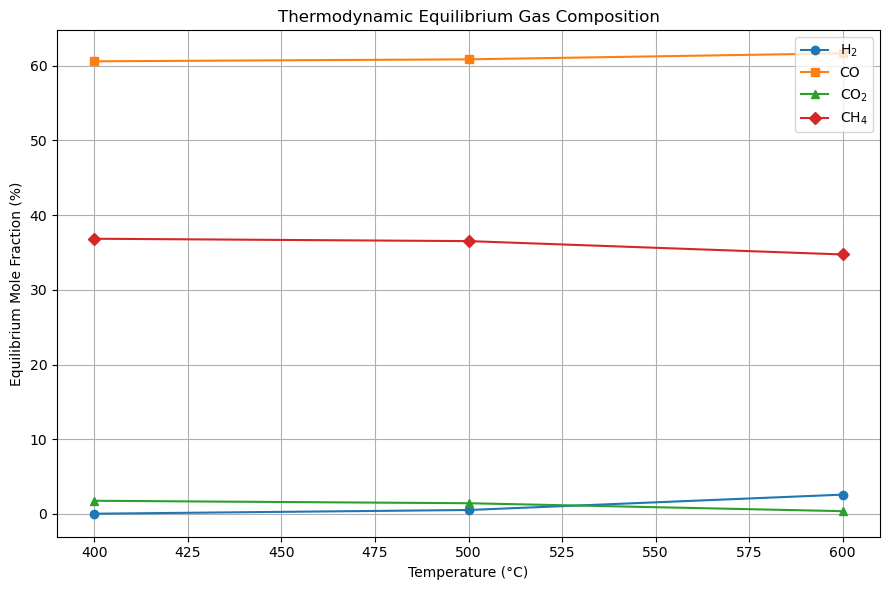

In [1]:
import cantera as ct
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Load Cantera mechanism
# --------------------------------------------------
gas = ct.Solution("gri30.yaml")

# --------------------------------------------------
# 2. Pinewood elemental composition
# --------------------------------------------------
feedstock_composition = {
    "C": 4.16,
    "H": 6.20,
    "O": 2.68,
    "N": 0.05
}

# Pressure
pressure_Pa = 101325.0   # 1 atm

# Temperatures
temperatures_C = [400, 500, 600]

# --------------------------------------------------
# 3. List to store results
# --------------------------------------------------
results = []

# --------------------------------------------------
# 4. Equilibrium calculation
# --------------------------------------------------
for temp_C in temperatures_C:

    temp_K = temp_C + 273.15

    # Set temperature, pressure and composition
    gas.TPX = temp_K, pressure_Pa, feedstock_composition

    # Calculate equilibrium at constant T and P
    gas.equilibrate("TP")

    # Store equilibrium mole percentages
    results.append({
        "Temperature (°C)": temp_C,
        "H2 (mol %)": gas["H2"].X[0] * 100,
        "CO (mol %)": gas["CO"].X[0] * 100,
        "CO2 (mol %)": gas["CO2"].X[0] * 100,
        "CH4 (mol %)": gas["CH4"].X[0] * 100,
        "O2 (mol %)": gas["O2"].X[0] * 100
    })

# --------------------------------------------------
# 5. Create a Pandas table
# --------------------------------------------------
results_df = pd.DataFrame(results)

print("\nThermodynamic Equilibrium Results")
print(results_df.to_string(index=False))

# --------------------------------------------------
# 6. Save the table as CSV
# --------------------------------------------------
results_df.to_csv(
    "thermodynamic_equilibrium_results.csv",
    index=False
)

# --------------------------------------------------
# 7. Plot the results
# --------------------------------------------------
plt.figure(figsize=(9, 6))

plt.plot(
    results_df["Temperature (°C)"],
    results_df["H2 (mol %)"],
    marker="o",
    label=r"H$_2$"
)

plt.plot(
    results_df["Temperature (°C)"],
    results_df["CO (mol %)"],
    marker="s",
    label="CO"
)

plt.plot(
    results_df["Temperature (°C)"],
    results_df["CO2 (mol %)"],
    marker="^",
    label=r"CO$_2$"
)

plt.plot(
    results_df["Temperature (°C)"],
    results_df["CH4 (mol %)"],
    marker="D",
    label=r"CH$_4$"
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Equilibrium Mole Fraction (%)")
plt.title("Thermodynamic Equilibrium Gas Composition")

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    "thermodynamic_equilibrium_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [2]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\SANDRA
['.anaconda', '.conda', '.continuum', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.python_history', '.virtual_documents', '.vscode', 'anaconda3', 'AppData', 'Application Data', 'Bar_Chart_Max_Yields.png', 'catalyst_data.csv', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'elements.txt', 'Experiment 1 (Target Temp - 600)', 'Favorites', 'FUNCTIONS.ipynb', 'gas_composition_vs_sampling_time.png', 'Gas_Yields_Table.csv', 'GetAtoms_.ipynb', 'grouped_bar_chart_5_gases.png', 'H2_vs_Time.png', 'haha', 'lala', 'Line_Graph_All_Gases.png', 'Links', 'LISTS.ipynb', 'Local Settings', 'LOOPS.ipynb', 'MATPLOTLIB.ipynb', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{8f69ed2f-dada-11ef-96ee-e388ec5d4eb4}.TM.blf', 'NTUSER.DAT{8f69ed2f-dada-11ef-96ee-e388ec5d4eb4}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{8f69ed2f-dada-11ef-96ee-e388ec5d4eb4}.TMContainer00000000000000000002.regtrans-ms', 'n